# Exercise 4


In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
plt.rcParams.update({"image.cmap": "viridis"})

**Linear Regression**

The goal of this exercise is to explore a simple linear regression problem based on Portugese white wine.

The dataset is based on
Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. **Modeling wine preferences by data mining from physicochemical properties**. Published in Decision Support Systems, Elsevier, 47(4):547-553, 2009.



In [15]:
# The code snippet below is responsible for downloading the dataset
# - for example when running via Google Colab.
#
# You can also directly download the file using the link if you work
# with a local setup (the !wget command will work either way assuming
# you are on a unix-based machine and have wget installed)
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

File ‘winequality-white.csv’ already there; not retrieving.



**Before we start**

The downloaded file contains data on 4989 wines. For each wine 11 features are recorded (column 0 to 10). The final columns contains the quality of the wine. This is what we want to predict. More information on the features and the quality measurement is provided in the original publication.

List of columns/features:
0. fixed acidity
1. volatile acidity
2. citric acid
3. residual sugar
4. chlorides
5. free sulfur dioxide
6. total sulfur dioxide
7. density
8. pH
9. sulphates
10. alcohol
11. quality



[file]: https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

In [16]:
# Before working with the data,
# we download and prepare all features

# load all examples from the file
data = np.genfromtxt('winequality-white.csv',delimiter=";",skip_header=1)

print(f"{data.shape = }")

# Prepare for proper training
rng = np.random.default_rng(1234)
rng.shuffle(data)  # randomly sort examples

# take the first 3000 examples for training
# (remember array slicing from last week)
X_train = data[:3000, :11]  # all features except last column
y_train = data[:3000, 11]  # quality column

# and the remaining examples for testing
X_test = data[3000:, :11]  # all features except last column
y_test = data[3000:, 11]  # quality column

print("First example:")
print("Features:", X_train[0])
print("Quality:", y_train[0])

data.shape = (4898, 12)
First example:
Features: [6.8000e+00 1.9000e-01 7.1000e-01 1.7500e+01 4.2000e-02 2.1000e+01
 1.1400e+02 9.9784e-01 2.8500e+00 5.0000e-01 9.5000e+00]
Quality: 6.0


# Problems


* First we want to understand the data better. Plot (`plt.hist`) the distribution of each of the features for the training data as well as the 2D distribution (either `plt.scatter` or `plt.hist2d`) of each feature versus quality. Also calculate the correlation coefficient (`np.corrcoef`) for each feature with quality. Which feature by itself seems most predictive for the quality?

* Calculate the linear regression weights. Numpy provides functions for matrix multiplication (`np.matmul`), matrix transposition (`.T`) and matrix inversion (`np.linalg.inv`).

* Use the weights to predict the quality for the test dataset. How
does your predicted quality compare with the true quality of the test data? Calculate the correlation coefficient between predicted and true quality and draw a scatter plot.

**Homework Submission**

When you submit your exercise sheet, please alwasy do two things

1) Generate a PDF of your iPython notebook. Submit this PDF through Studium (Uppsala)/Moodle (Dortmund).

2) Provide a link to your google colab notebook so that we can directly execute and test your code. To do that click on "share", change access to "anyone with the link", copy the link and add it as a comment to your submission on Studium (Uppsala)/Moodle (Dortmund).

# Hints

Formally, we want to find weights $w_i$ that minimize:
$$
\sum_{j}\left(\sum_{i} X_{i j} w_{i}-y_{j}\right)^{2}
$$
The index $i$ denotes the different features (properties of the wines) while the index $j$ runs over the different wines. The matrix $X_{ij}$ contains the training data, $y_j$ is the 'true' quality for sample $j$. The weights can be found by taking the first derivative of the above expression with respect to the weights and setting it to zero (the standard strategy for finding an extremum), and solving the corresponding system of equations (for a detailed derivation, see [here](https://en.wikipedia.org/wiki/Ordinary_least_squares)). The result is:
$$
\overrightarrow{\mathbf{w}}=\left(\mathbf{X}^{T} \mathbf{X}\right)^{-1} \mathbf{X}^{T} \overrightarrow{\mathbf{y}}
$$

In the end, you should have as many components of $w_i$ as there are features in the data (i.e. eleven in this case).

You can use `.shape` to inspect the dimensions of numpy tensors.


--- Feature Analysis ---


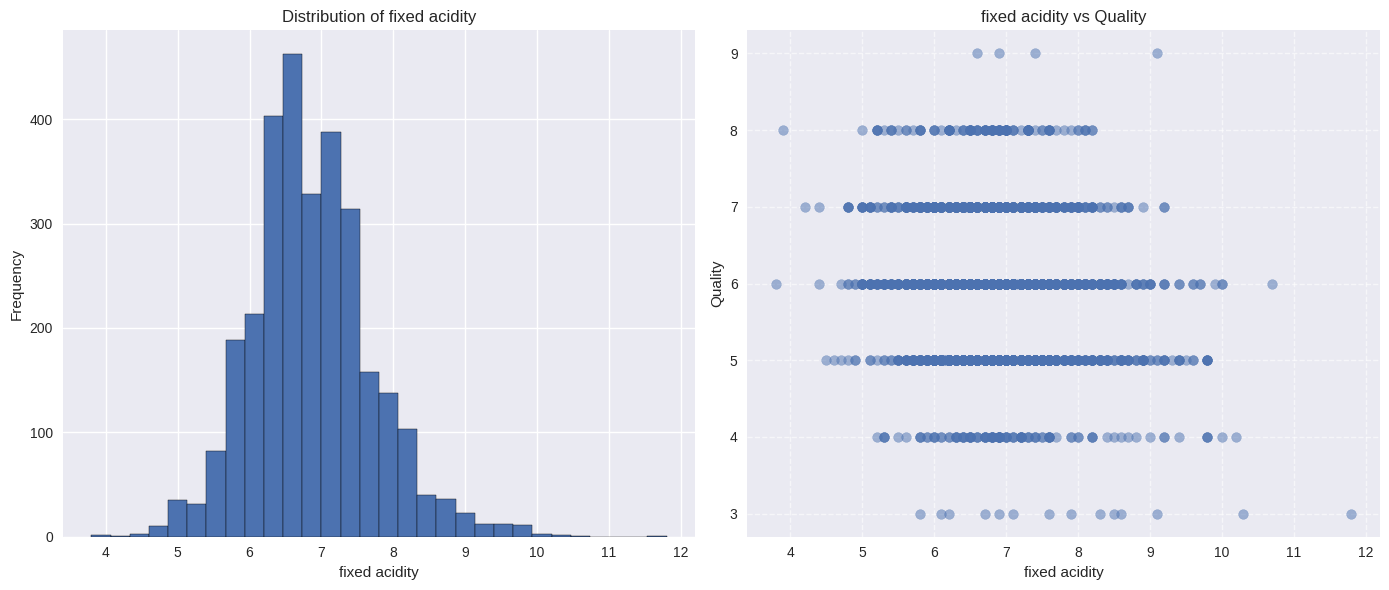

Correlation between fixed acidity and Quality: -0.1276

--------------------------------------------------



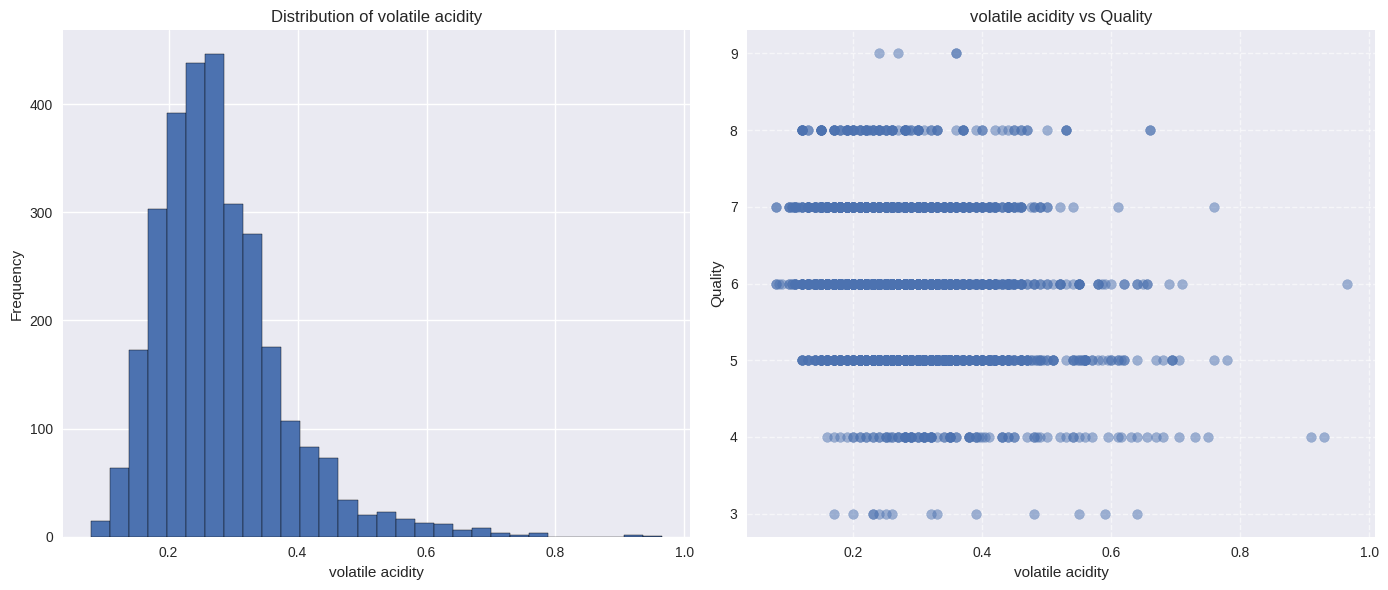

Correlation between volatile acidity and Quality: -0.2069

--------------------------------------------------



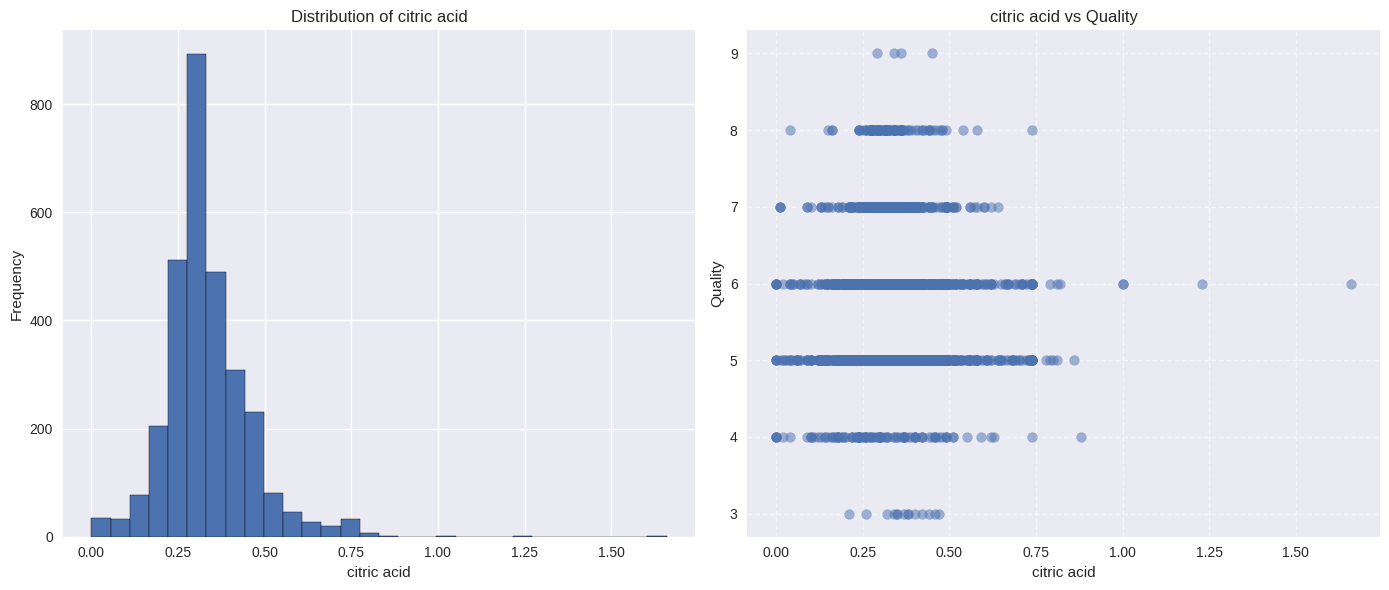

Correlation between citric acid and Quality: -0.0072

--------------------------------------------------



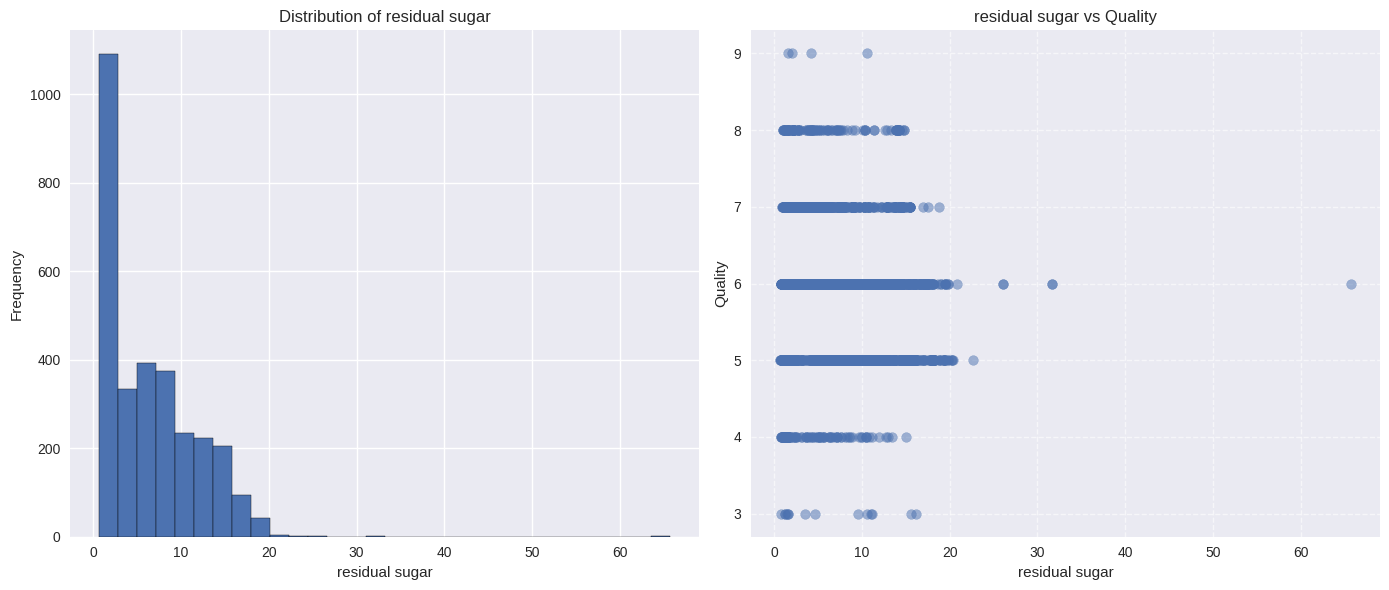

Correlation between residual sugar and Quality: -0.0949

--------------------------------------------------



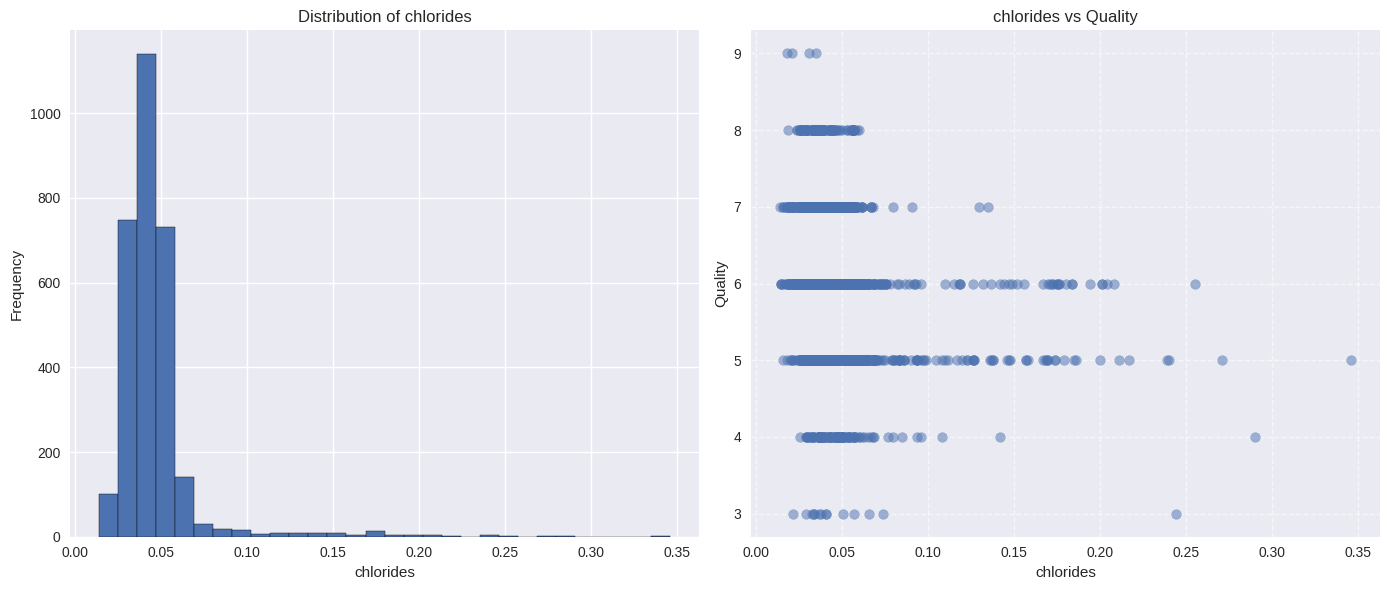

Correlation between chlorides and Quality: -0.2099

--------------------------------------------------



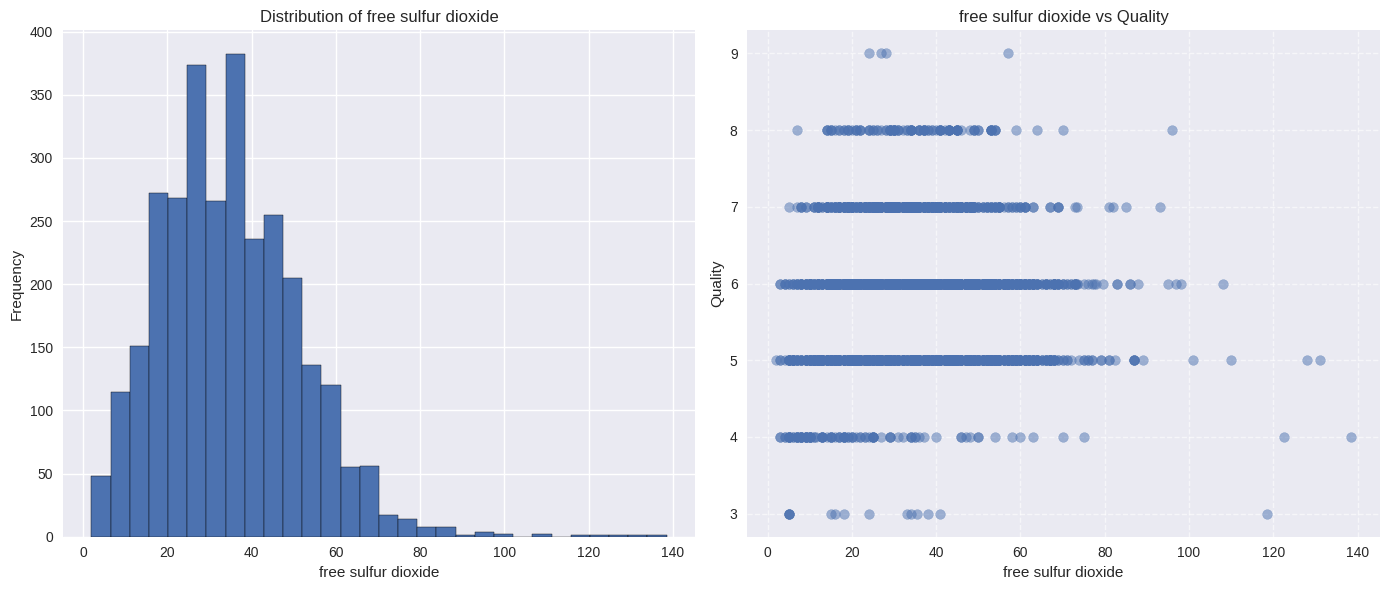

Correlation between free sulfur dioxide and Quality: 0.0179

--------------------------------------------------



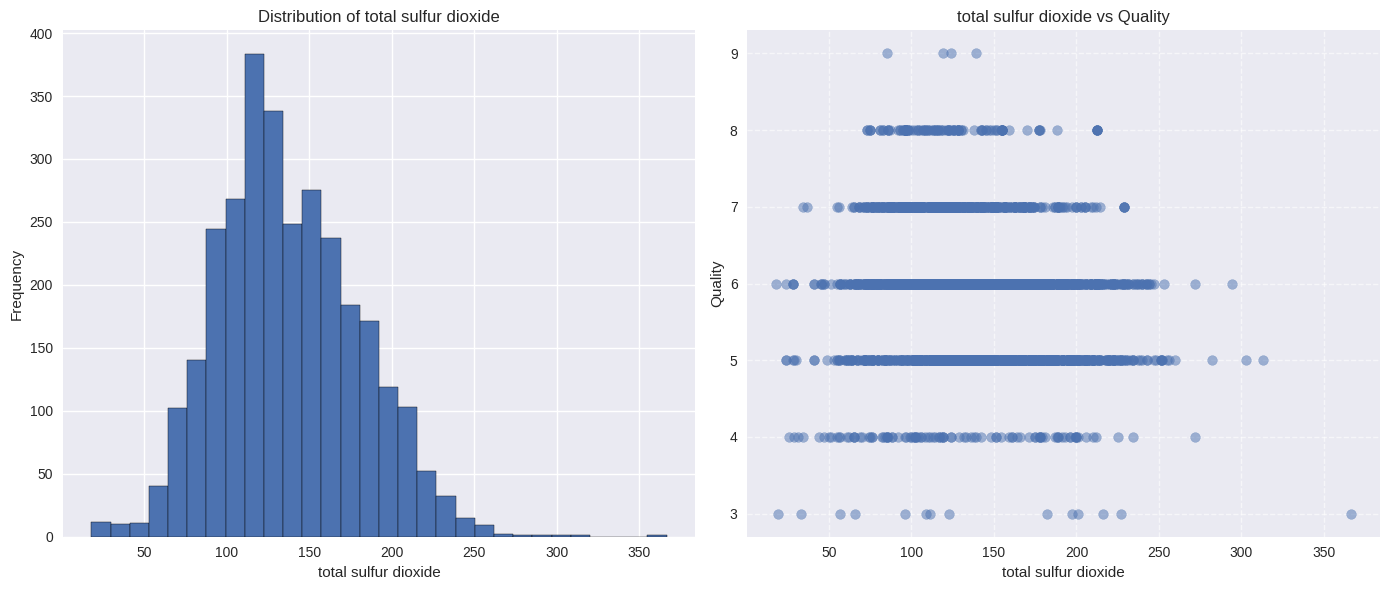

Correlation between total sulfur dioxide and Quality: -0.1720

--------------------------------------------------



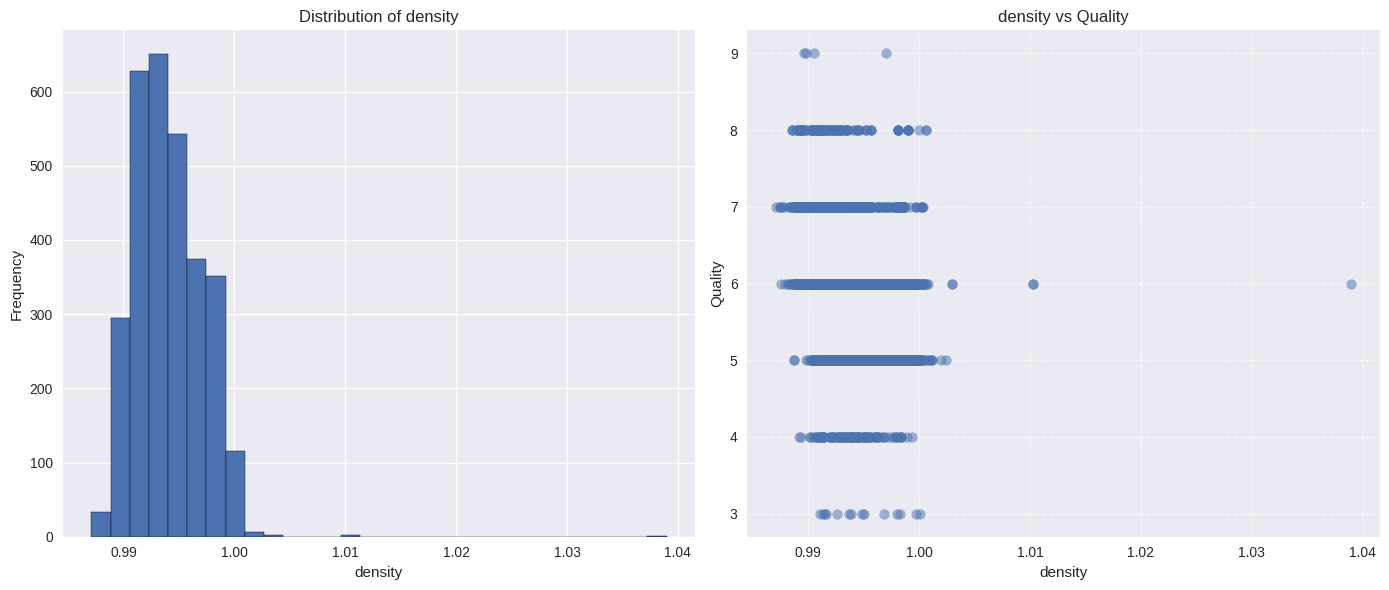

Correlation between density and Quality: -0.2999

--------------------------------------------------



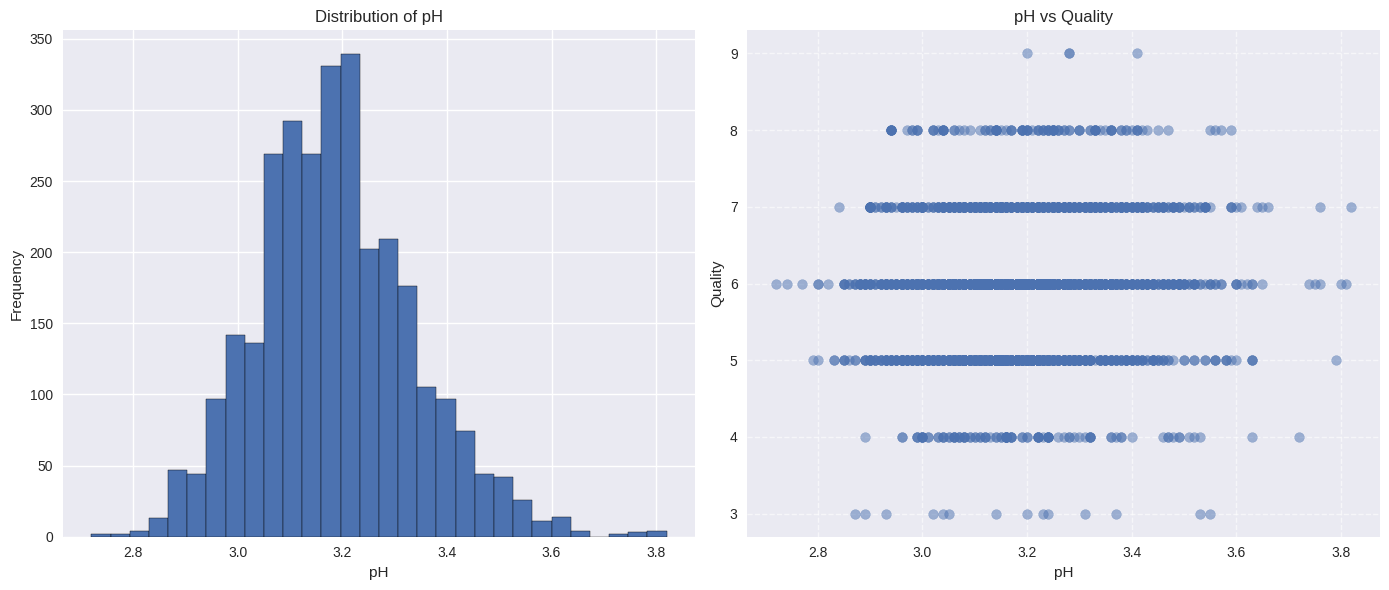

Correlation between pH and Quality: 0.1038

--------------------------------------------------



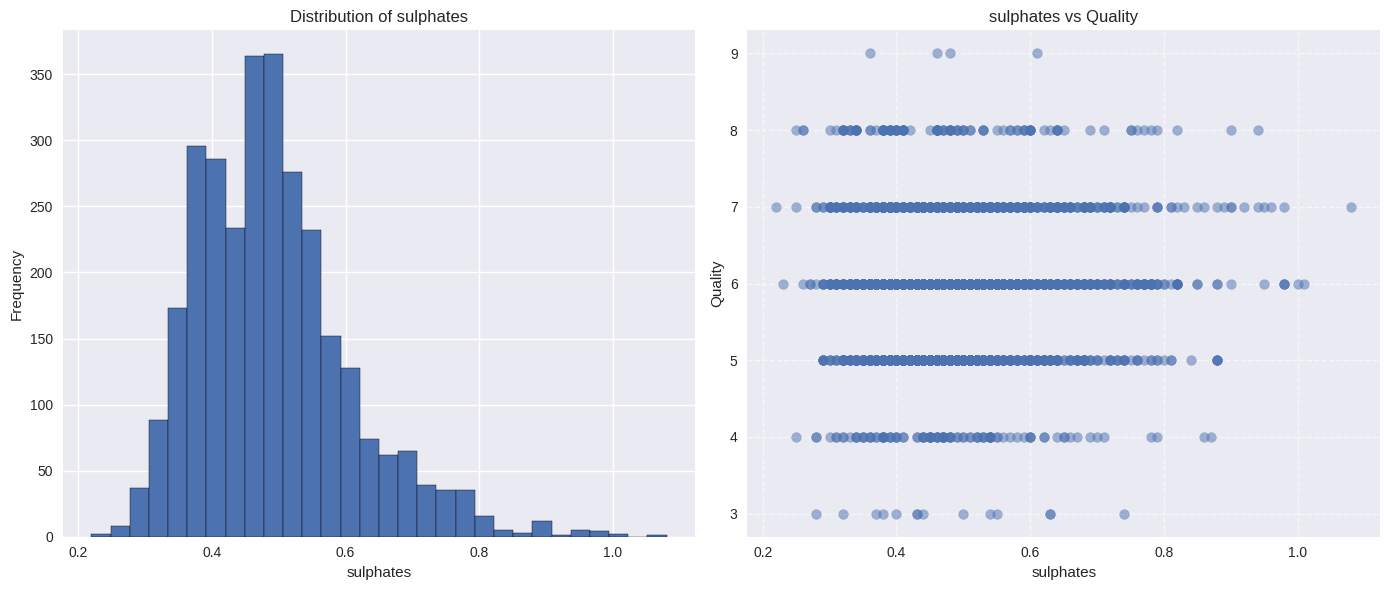

Correlation between sulphates and Quality: 0.0516

--------------------------------------------------



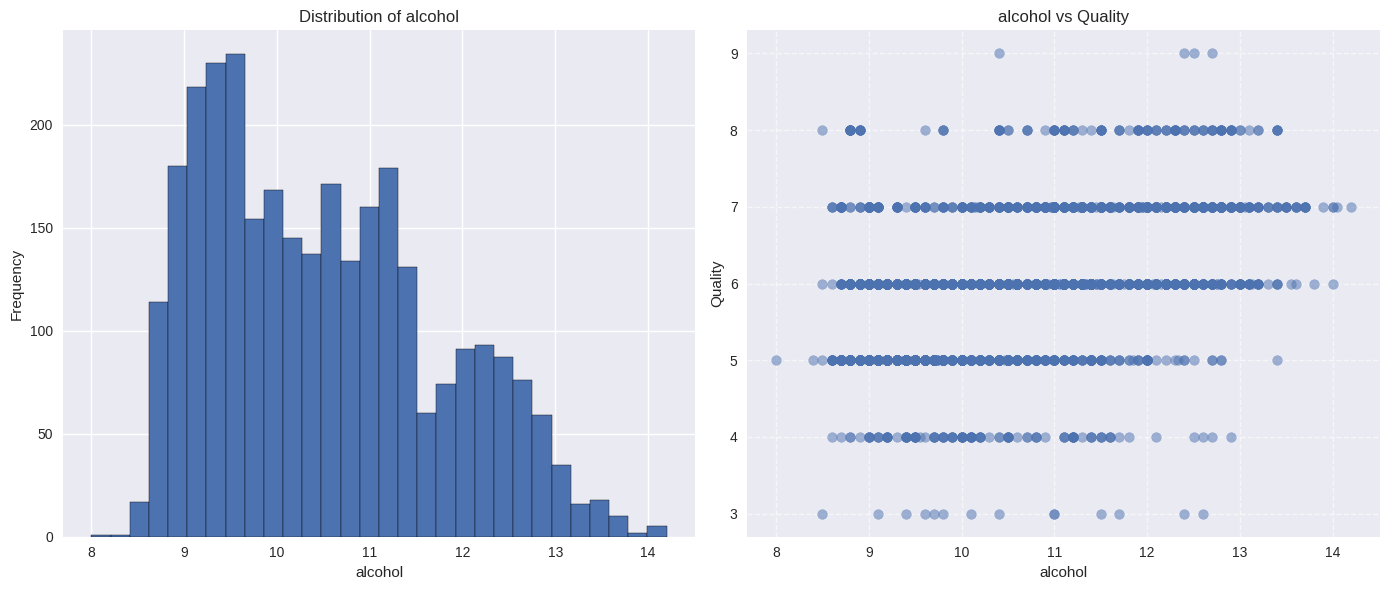

Correlation between alcohol and Quality: 0.4285

--------------------------------------------------

The feature that seems most predictive for quality (based on highest absolute correlation) is: alcohol (correlation: 0.4285)


In [17]:
feature_names = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol"
]

num_features = X_train.shape[1]
correlations = []

print("--- Feature Analysis ---")

for i in range(num_features):
    feature_data = X_train[:, i]
    feature_name = feature_names[i]

    # Plot histogram of the feature
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.hist(feature_data, bins=30, edgecolor='black')
    plt.title(f'Distribution of {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Frequency')

    # Plot 2D distribution (feature vs quality)
    plt.subplot(1, 2, 2)
    plt.scatter(feature_data, y_train, alpha=0.5)
    plt.title(f'{feature_name} vs Quality')
    plt.xlabel(feature_name)
    plt.ylabel('Quality')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Calculate and print correlation coefficient
    corr_matrix = np.corrcoef(feature_data, y_train)
    correlation = corr_matrix[0, 1]
    correlations.append((feature_name, correlation))
    print(f'Correlation between {feature_name} and Quality: {correlation:.4f}')
    print("\n" + "-" * 50 + "\n") # Separator for clarity

# Find the feature with the highest absolute correlation
most_predictive_feature = None
max_abs_correlation = -1

for name, corr in correlations:
    if abs(corr) > max_abs_correlation:
        max_abs_correlation = abs(corr)
        most_predictive_feature = name

print(f"The feature that seems most predictive for quality (based on highest absolute correlation) is: {most_predictive_feature} (correlation: {max_abs_correlation:.4f})")


## Feature Analysis Summary

After analyzing each feature's distribution, its 2D distribution with quality, and calculating its correlation coefficient with quality, we found the following:

The feature that seems most predictive for quality (based on the highest absolute correlation) is **alcohol** with a correlation coefficient of approximately **0.4285**.

This suggests that higher alcohol content tends to be associated with higher wine quality, although correlation does not imply causation and other factors are also at play.

In [18]:
X_train_bias = np.concatenate((np.ones((X_train.shape[0], 1)), X_train), axis=1)

# Calculate the weights using the formula: w = (X^T X)^-1 X^T y
# X^T X
X_T_X = np.matmul(X_train_bias.T, X_train_bias)

# (X^T X)^-1
X_T_X_inv = np.linalg.inv(X_T_X)

# X^T y
X_T_y = np.matmul(X_train_bias.T, y_train)

# weights = (X^T X)^-1 X^T y
weights = np.matmul(X_T_X_inv, X_T_y)

print("Calculated Linear Regression Weights:")
# print bias weight (first element) separately for clarity if needed
# print(f"Bias weight: {weights[0]:.4f}")
# print(f"Feature weights: {weights[1:]}")
print(weights)


Calculated Linear Regression Weights:
[ 1.10236555e+02  1.97051124e-02 -1.97246956e+00  3.38869498e-03
  6.43013084e-02 -5.74013320e-01  5.22151568e-03 -5.99515349e-04
 -1.09453438e+02  5.28044869e-01  5.10629056e-01  2.33036086e-01]


## Explanation of Linear Regression Weights

The calculated `weights` array represents the coefficients that our linear regression model learned to predict wine quality.

*   The **first value** in the `weights` array (e.g., `1.10236555e+02` from the output above) is the **bias term** (or intercept). This represents the predicted quality when all feature values are zero.
*   The **subsequent values** in the `weights` array correspond to the coefficients for each of the 11 features, in the same order as they appear in `X_train`.

Each weight indicates the **direction and strength** of that particular feature's influence on the predicted wine quality:
*   A **positive weight** means that as the value of that feature increases, the predicted wine quality tends to increase.
*   A **negative weight** means that as the value of that feature increases, the predicted wine quality tends to decrease.
*   The **magnitude (absolute value)** of the weight indicates the strength of this relationship. A larger absolute value suggests a stronger influence on the predicted quality.

For example, if the weight for 'alcohol' is positive and relatively large, it suggests that wines with higher alcohol content tend to have higher predicted quality.


--- Prediction Analysis ---
First 5 true qualities: [6. 6. 5. 7. 6.]
First 5 predicted qualities: [5.55 6.02 5.53 6.25 6.8 ]
Correlation coefficient between predicted and true quality: 0.5292


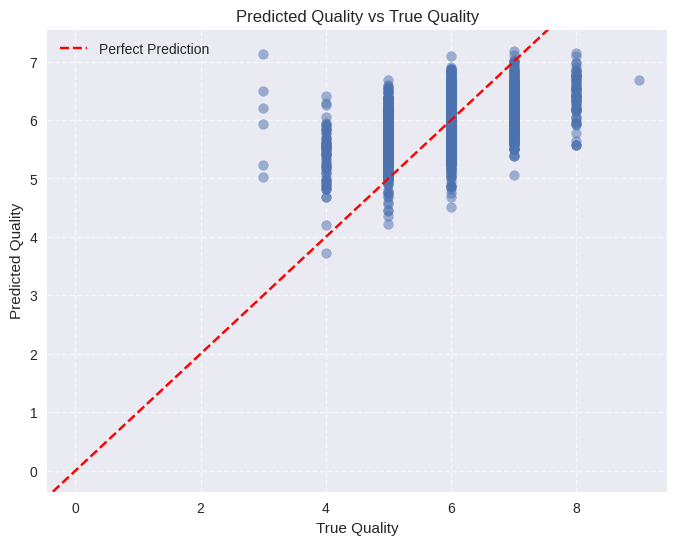

In [19]:
X_test_bias = np.concatenate((np.ones((X_test.shape[0], 1)), X_test), axis=1)

# Predict quality for the test dataset
y_pred = np.matmul(X_test_bias, weights)

print("--- Prediction Analysis ---")

# Compare predicted quality with true quality
print(f"First 5 true qualities: {y_test[:5]}")
print(f"First 5 predicted qualities: {y_pred[:5].round(2)}")

# Calculate the correlation coefficient between predicted and true quality
corr_pred_true = np.corrcoef(y_pred, y_test)[0, 1]
print(f"Correlation coefficient between predicted and true quality: {corr_pred_true:.4f}")

# Draw a scatter plot of predicted vs true quality
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('Predicted Quality vs True Quality')
plt.xlabel('True Quality')
plt.ylabel('Predicted Quality')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axline([0, 0], [1, 1], color='red', linestyle='--', label='Perfect Prediction') # Add a y=x line for reference
plt.legend()
plt.show()

In [20]:
# Calculate the difference between true and predicted qualities
differences = y_test - y_pred

# Square each of these differences
squared_differences = differences**2

# Calculate the mean of these squared differences to get the Mean Squared Error (MSE)
mse = np.mean(squared_differences)

# Print
print(f"Mean Squared Error (MSE) on the test data: {mse:.4f}")

Mean Squared Error (MSE) on the test data: 0.5559


### Prediction Analysis Summary

The linear regression model was used to predict the quality of white wines on the test dataset. Comparing the first 5 true qualities `[6., 6., 5., 7., 6.]` with their corresponding predicted qualities `[5.55, 6.02, 5.53, 6.25, 6.8 ]`, we can observe that the predictions are reasonably close to the true values, although not perfectly accurate for every instance.

The calculated correlation coefficient between the predicted and true quality is **0.5292**. This indicates a moderate positive linear relationship, suggesting that as the true quality increases, the predicted quality also tends to increase.

The scatter plot of 'Predicted Quality vs True Quality' visually confirms this moderate correlation. While there is a general upward trend, indicating that higher true qualities correspond to higher predicted qualities, the points are somewhat spread out around the red 'Perfect Prediction' line (y=x). This spread suggests that the model's predictions are not perfectly precise for all wines, with some under-predictions and over-predictions. The clustering of points around certain quality values (e.g., around quality 6) is also visible, reflecting the distribution of quality ratings in the dataset.

## Summary:

### Data Analysis Key Findings

*   The most predictive feature for wine quality, based on the highest absolute correlation, is **alcohol**, with a correlation coefficient of approximately **0.4285**. This suggests a positive relationship where higher alcohol content tends to be associated with higher wine quality.
*   The linear regression model's `weights` array consists of a bias term and coefficients for each of the 11 features. These coefficients indicate the direction (positive or negative) and strength of each feature's influence on the predicted wine quality.
*   The model's predictions show a moderate positive linear relationship with the true quality, evidenced by a correlation coefficient of **0.5292** between predicted and true quality.
*   A scatter plot of predicted versus true quality indicates a general upward trend, but points are somewhat dispersed around the ideal "perfect prediction" line, suggesting that while the model captures the overall trend, its predictions are not perfectly precise for all wines, exhibiting some over and under-predictions.

### Insights or Next Steps

*   The moderate correlation between alcohol content and wine quality, and between predicted and true quality, suggests that while alcohol is an important factor, other features and potentially more complex models could further improve prediction accuracy.
*   To enhance model performance, further analysis could focus on features with higher absolute weights from the linear regression model, exploring non-linear relationships, or considering advanced regression techniques beyond simple linear regression.
